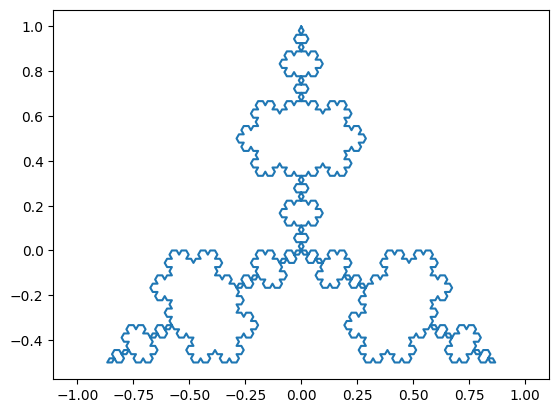

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def koch_curve(p1, p2, order):
    if order == 0:
        return [p1, p2]
    # 1/3, 2/3 ভাগ
    x1, y1 = p1
    x2, y2 = p2
    a = (x1 + (x2 - x1) / 3, y1 + (y2 - y1) / 3)
    b = (x1 + 2 * (x2 - x1) / 3, y1 + 2 * (y2 - y1) / 3)
    # peak বের করা (60° ঘুরিয়ে)
    dx, dy = b[0] - a[0], b[1] - a[1]
    angle = np.pi / 3
    peak = (
        a[0] + dx * np.cos(angle) - dy * np.sin(angle),
        a[1] + dx * np.sin(angle) + dy * np.cos(angle)
    )
    # চারটি অংশে recursion
    return (koch_curve(p1, a, order - 1)[:-1] +
            koch_curve(a, peak, order - 1)[:-1] +
            koch_curve(peak, b, order - 1)[:-1] +
            koch_curve(b, p2, order - 1))

def koch_snowflake(order=4, scale=1.0): 
    # সমবাহু ত্রিভুজের তিনটি শীর্ষ
    p1 = (0, scale)
    p2 = (-scale * np.sin(np.pi / 3), -scale / 2)
    p3 = (scale * np.sin(np.pi / 3), -scale / 2)

    side1 = koch_curve(p1, p2, order)[:-1]
    side2 = koch_curve(p2, p3, order)[:-1]
    side3 = koch_curve(p3, p1, order)
    pts = side1 + side2 + side3
    x, y = zip(*pts)
    return x, y

if __name__ == "__main__":
    x, y = koch_snowflake(order=4)
    plt.plot(x, y)
    plt.axis('equal')
    plt.show()
